# Plant Disease Classification with a CNN — PlantVillage Dataset
### Thesis-Ready Notebook: Training, Evaluation Metrics, and Report Diagrams

This notebook extends the original training pipeline with everything needed for a
thesis results chapter:

| Addition | Why it matters for the thesis |
|---|---|
| **70/15/15 train/val/test split** | The original notebook only had train/validation. A held-out **test set** is required to report unbiased final accuracy/precision/recall. |
| **Early stopping + LR scheduler** | Finds an *efficient* number of epochs automatically — training stops as soon as validation loss stops improving, instead of a fixed guess. |
| **Architecture diagram** | A block diagram of the CNN, suitable for the "Methodology" chapter. |
| **Training/validation curves (loss & accuracy)** | Shows convergence behaviour and confirms the model isn't over/under-fitting. |
| **Confusion matrix (counts + normalized)** | Standard diagnostic figure for multi-class classification. |
| **Precision / Recall / F1 — overall and per-class** | The "evaluation matrix" requested — macro and weighted averages plus a full classification report. |
| **ROC curves (micro/macro-average, one-vs-rest)** | Additional evaluation diagram commonly expected in thesis results chapters. |
| **Metrics summary table** | A clean table to paste directly into the report. |
| **Single-image test with confidence chart** | Shows precision of an individual prediction, not just the aggregate. |

> **Note:** This notebook is written to run on Kaggle with the PlantVillage dataset
> attached and a GPU accelerator turned on (same setup as the original notebook).
> Run all cells top to bottom.

## Step 1: Setup and Import Libraries
Ensure the PlantVillage dataset is attached and the GPU accelerator (T4 x2) is turned on.

In [1]:
import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Step 2: Load the Dataset and Create Train / Validation / Test Splits

We resize images to 224x224, normalize using standard ImageNet statistics, and apply
light data augmentation **only to the training set** (random flips/rotation/color
jitter). A 70/15/15 split gives a held-out **test set** that the model never sees
during training or model selection — this is what we report final precision/accuracy on.

> Update `data_dir` if your Kaggle dataset folder structure differs.

In [2]:
# Standard path when attaching the PlantVillage dataset on Kaggle
data_dir = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Load file paths/labels once, without a transform (transform is applied per-split below)
base_dataset = datasets.ImageFolder(root=data_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
print(f"Total classes: {num_classes}")
print(f"Total images : {len(base_dataset)}")

Total classes: 38
Total images : 54305


In [3]:
class TransformSubset(Dataset):
    """Wraps a subset of indices from a base ImageFolder dataset and applies its own
    transform. This is needed because train/val/test require different transforms
    (augmentation only on train) while still sharing the same underlying file list."""
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.base_dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label


# 70% train / 15% validation / 15% test split
total_size = len(base_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)
shuffled_indices = torch.randperm(total_size, generator=generator).tolist()

train_idx = shuffled_indices[:train_size]
val_idx = shuffled_indices[train_size:train_size + val_size]
test_idx = shuffled_indices[train_size + val_size:]

train_dataset = TransformSubset(base_dataset, train_idx, train_transform)
val_dataset = TransformSubset(base_dataset, val_idx, eval_transform)
test_dataset = TransformSubset(base_dataset, test_idx, eval_transform)

print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")

# With 2x T4 16GB GPUs, we can handle a larger batch size
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

Train: 38013 | Validation: 8145 | Test: 8147


## Step 3: Define the CNN Architecture

Same core architecture as the original (3 conv blocks + 2 FC layers), with
**BatchNorm** added after every convolution. BatchNorm stabilizes and speeds up
convergence, which directly helps reach a good model in *fewer epochs* — relevant
to the "efficient epoch" goal in Step 7.

In [4]:
class PlantVillageCNN(nn.Module):
    def __init__(self, num_classes):
        super(PlantVillageCNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = PlantVillageCNN(num_classes=num_classes)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

Total parameters     : 51,493,926
Trainable parameters : 51,493,926


## Step 4: Architecture Diagram (for the Methodology chapter)

A block diagram of the network, generated directly with matplotlib so it can be
exported as a clean, editable image for the report.

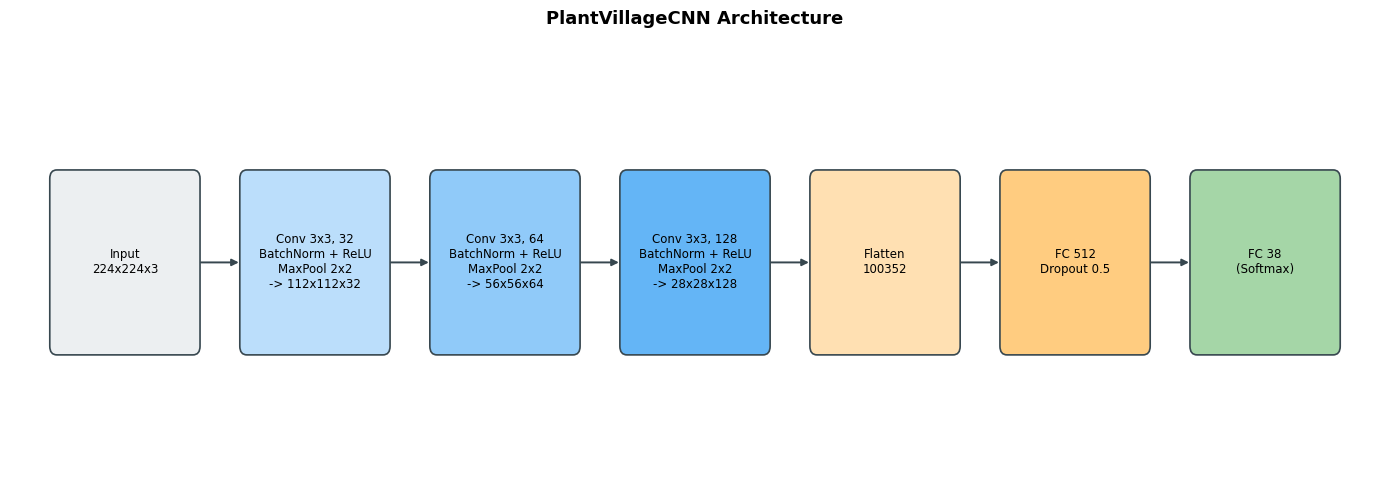

In [5]:
from matplotlib.patches import FancyBboxPatch

def draw_architecture_diagram(num_classes, save_path=None):
    fig, ax = plt.subplots(figsize=(14, 5))

    blocks = [
        ("Input\n224x224x3", "#ECEFF1"),
        ("Conv 3x3, 32\nBatchNorm + ReLU\nMaxPool 2x2\n-> 112x112x32", "#BBDEFB"),
        ("Conv 3x3, 64\nBatchNorm + ReLU\nMaxPool 2x2\n-> 56x56x64", "#90CAF9"),
        ("Conv 3x3, 128\nBatchNorm + ReLU\nMaxPool 2x2\n-> 28x28x128", "#64B5F6"),
        ("Flatten\n100352", "#FFE0B2"),
        ("FC 512\nDropout 0.5", "#FFCC80"),
        (f"FC {num_classes}\n(Softmax)", "#A5D6A7"),
    ]

    n = len(blocks)
    box_w, box_h = 1.6, 1.6
    gap = 0.55
    total_w = n * box_w + (n - 1) * gap
    start_x = -total_w / 2

    centers = []
    for i, (label, color) in enumerate(blocks):
        x = start_x + i * (box_w + gap)
        y = -box_h / 2
        box = FancyBboxPatch((x, y), box_w, box_h,
                              boxstyle="round,pad=0.05,rounding_size=0.08",
                              linewidth=1.2, edgecolor="#37474F", facecolor=color)
        ax.add_patch(box)
        ax.text(x + box_w / 2, 0, label, ha="center", va="center", fontsize=8.5)
        centers.append(x + box_w / 2)

    for i in range(n - 1):
        ax.annotate("", xy=(centers[i + 1] - box_w / 2 - 0.03, 0),
                     xytext=(centers[i] + box_w / 2 + 0.03, 0),
                     arrowprops=dict(arrowstyle="-|>", color="#37474F", lw=1.4))

    ax.set_xlim(start_x - 0.5, start_x + total_w + 0.5)
    ax.set_ylim(-2, 2)
    ax.axis("off")
    ax.set_title("PlantVillageCNN Architecture", fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


draw_architecture_diagram(num_classes, save_path="architecture_diagram.png")

## Step 5: Enable Dual GPU Training (Tesla T4 x2)
Wraps the model in `DataParallel` if more than one GPU is available, as in the
original notebook.

In [6]:
if torch.cuda.device_count() > 1:
    print(f"Utilizing {torch.cuda.device_count()} GPUs via DataParallel!")
    model = nn.DataParallel(model)

model = model.to(device)

Utilizing 2 GPUs via DataParallel!


## Step 6: Early Stopping (for an Efficient Epoch Count)

Rather than guessing a fixed epoch count, training is allowed to run up to
`MAX_EPOCHS`, but stops automatically once the validation loss hasn't improved
for `PATIENCE` consecutive epochs. The best-performing weights (lowest validation
loss) are checkpointed and reloaded after training — this is what makes the
epoch budget *efficient*: no wasted compute past the point of useful learning,
and no early cutoff before the model has converged.

In [7]:
class EarlyStopping:
    """Stops training when validation loss has not improved for `patience` epochs
    and keeps the best checkpoint on disk."""
    def __init__(self, patience=5, min_delta=1e-4, path='best_model.pt'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best_loss = float('inf')
        self.counter = 0
        self.best_epoch = 0
        self.early_stop = False

    def __call__(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

## Step 7: Training & Validation Loop

`MAX_EPOCHS = 25` is an upper bound, not a target — `EarlyStopping` (patience = 5)
combined with `ReduceLROnPlateau` typically converges on PlantVillage well before
that ceiling, which is what determines the *actual, efficient* number of epochs
for this dataset/architecture combination.

In [8]:
MAX_EPOCHS = 25
PATIENCE = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
early_stopper = EarlyStopping(patience=PATIENCE, path='best_model.pt')

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
start_time = time.time()

for epoch in range(MAX_EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss, running_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = running_correct / len(train_loader.dataset)

    # --- Validation Phase ---
    model.eval()
    val_loss_total, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss_total += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    epoch_val_loss = val_loss_total / len(val_loader.dataset)
    epoch_val_acc = val_correct / len(val_loader.dataset)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{MAX_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    early_stopper(epoch_val_loss, model, epoch + 1)
    if early_stopper.early_stop:
        print(f"\nEarly stopping triggered after {epoch+1} epochs. "
              f"Best epoch: {early_stopper.best_epoch} (Val Loss: {early_stopper.best_loss:.4f})")
        break

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.1f} minutes.")
print(f"Best model checkpoint is from epoch {early_stopper.best_epoch}.")

# Reload the best checkpoint (not necessarily the last epoch) before evaluation
model.load_state_dict(torch.load('best_model.pt'))

Epoch [1/25] Train Loss: 3.6213 Acc: 0.2734 | Val Loss: 2.0118 Acc: 0.4379
Epoch [2/25] Train Loss: 2.3058 Acc: 0.3437 | Val Loss: 1.6158 Acc: 0.5470
Epoch [3/25] Train Loss: 2.1593 Acc: 0.3757 | Val Loss: 1.3964 Acc: 0.6110
Epoch [4/25] Train Loss: 2.0694 Acc: 0.3944 | Val Loss: 1.2818 Acc: 0.6306
Epoch [5/25] Train Loss: 1.9815 Acc: 0.4185 | Val Loss: 1.2702 Acc: 0.6700
Epoch [6/25] Train Loss: 1.8804 Acc: 0.4423 | Val Loss: 1.1683 Acc: 0.6728
Epoch [7/25] Train Loss: 1.7901 Acc: 0.4604 | Val Loss: 1.0666 Acc: 0.7036
Epoch [8/25] Train Loss: 1.7348 Acc: 0.4694 | Val Loss: 0.9409 Acc: 0.7293
Epoch [9/25] Train Loss: 1.6339 Acc: 0.4968 | Val Loss: 0.8498 Acc: 0.7554
Epoch [10/25] Train Loss: 1.5217 Acc: 0.5288 | Val Loss: 0.7678 Acc: 0.7623
Epoch [11/25] Train Loss: 1.3951 Acc: 0.5680 | Val Loss: 0.6604 Acc: 0.8098
Epoch [12/25] Train Loss: 1.3016 Acc: 0.5910 | Val Loss: 0.6391 Acc: 0.8257
Epoch [13/25] Train Loss: 1.1966 Acc: 0.6204 | Val Loss: 0.5351 Acc: 0.8556
Epoch [14/25] Train L

<All keys matched successfully>

## Step 8: Training Curves — Loss & Accuracy (Thesis Diagram)

These two curves are a standard figure in a results chapter: they show
convergence behaviour and let a reader judge over/under-fitting at a glance.
The dashed line marks the epoch selected by early stopping.

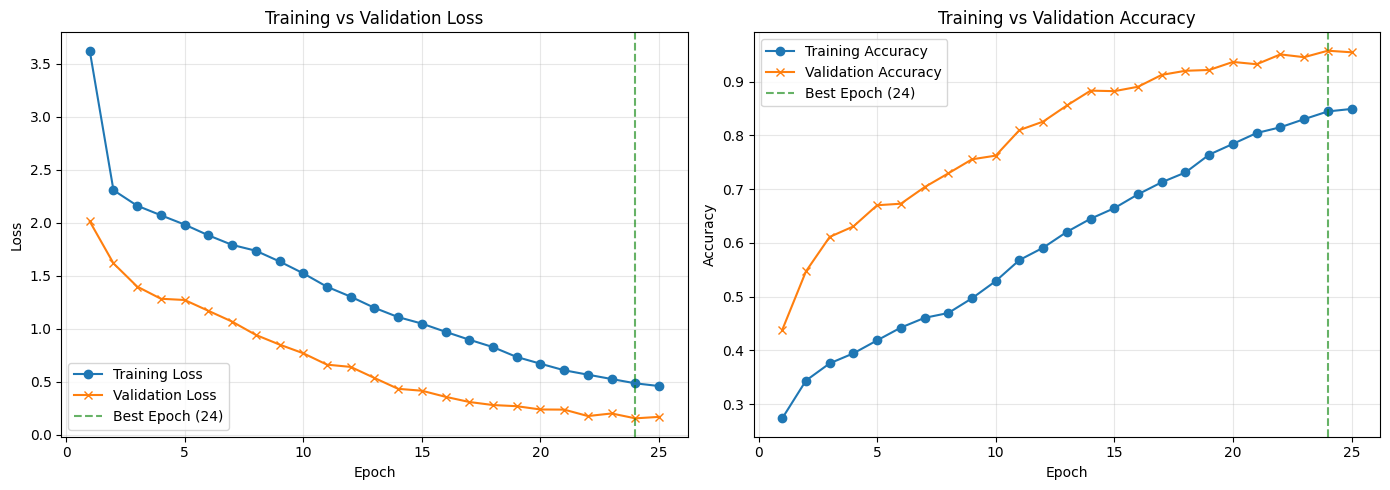

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], marker='o', label='Training Loss')
axes[0].plot(epochs_range, history['val_loss'], marker='x', label='Validation Loss')
axes[0].axvline(early_stopper.best_epoch, color='green', linestyle='--', alpha=0.6,
                 label=f'Best Epoch ({early_stopper.best_epoch})')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], marker='o', label='Training Accuracy')
axes[1].plot(epochs_range, history['val_acc'], marker='x', label='Validation Accuracy')
axes[1].axvline(early_stopper.best_epoch, color='green', linestyle='--', alpha=0.6,
                 label=f'Best Epoch ({early_stopper.best_epoch})')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Test Set Evaluation — Accuracy, Precision, Recall, F1

This is the core **evaluation matrix** for the thesis: the model is evaluated on
the held-out **test set** (images never used for training or for picking the best
epoch), so these numbers represent unbiased, generalizable performance.

In [10]:
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

test_accuracy = accuracy_score(all_labels, all_preds)
precision_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

precision_weighted = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall_weighted = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print("=" * 55)
print("TEST SET PERFORMANCE")
print("=" * 55)
print(f"Test Accuracy        : {test_accuracy*100:.2f}%")
print(f"Precision (macro)    : {precision_macro:.4f}")
print(f"Recall    (macro)    : {recall_macro:.4f}")
print(f"F1-score  (macro)    : {f1_macro:.4f}")
print(f"Precision (weighted) : {precision_weighted:.4f}")
print(f"Recall    (weighted) : {recall_weighted:.4f}")
print(f"F1-score  (weighted) : {f1_weighted:.4f}")
print("=" * 55)

print("\nFull Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

TEST SET PERFORMANCE
Test Accuracy        : 95.75%
Precision (macro)    : 0.9524
Recall    (macro)    : 0.9322
F1-score  (macro)    : 0.9396
Precision (weighted) : 0.9580
Recall    (weighted) : 0.9575
F1-score  (weighted) : 0.9566

Full Classification Report:

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.84      0.88        91
                                 Apple___Black_rot       0.93      0.97      0.95        87
                          Apple___Cedar_apple_rust       1.00      0.89      0.94        37
                                   Apple___healthy       0.97      0.96      0.97       270
                               Blueberry___healthy       0.93      1.00      0.97       198
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       176
                 Cherry_(including_sour)___healthy       0.96      0.96      0.96       125
Co

## Step 10: Confusion Matrix (Diagram)

Both raw counts and row-normalized versions are plotted — normalized values make
it easier to spot which specific diseases the model confuses, regardless of class
size imbalance.

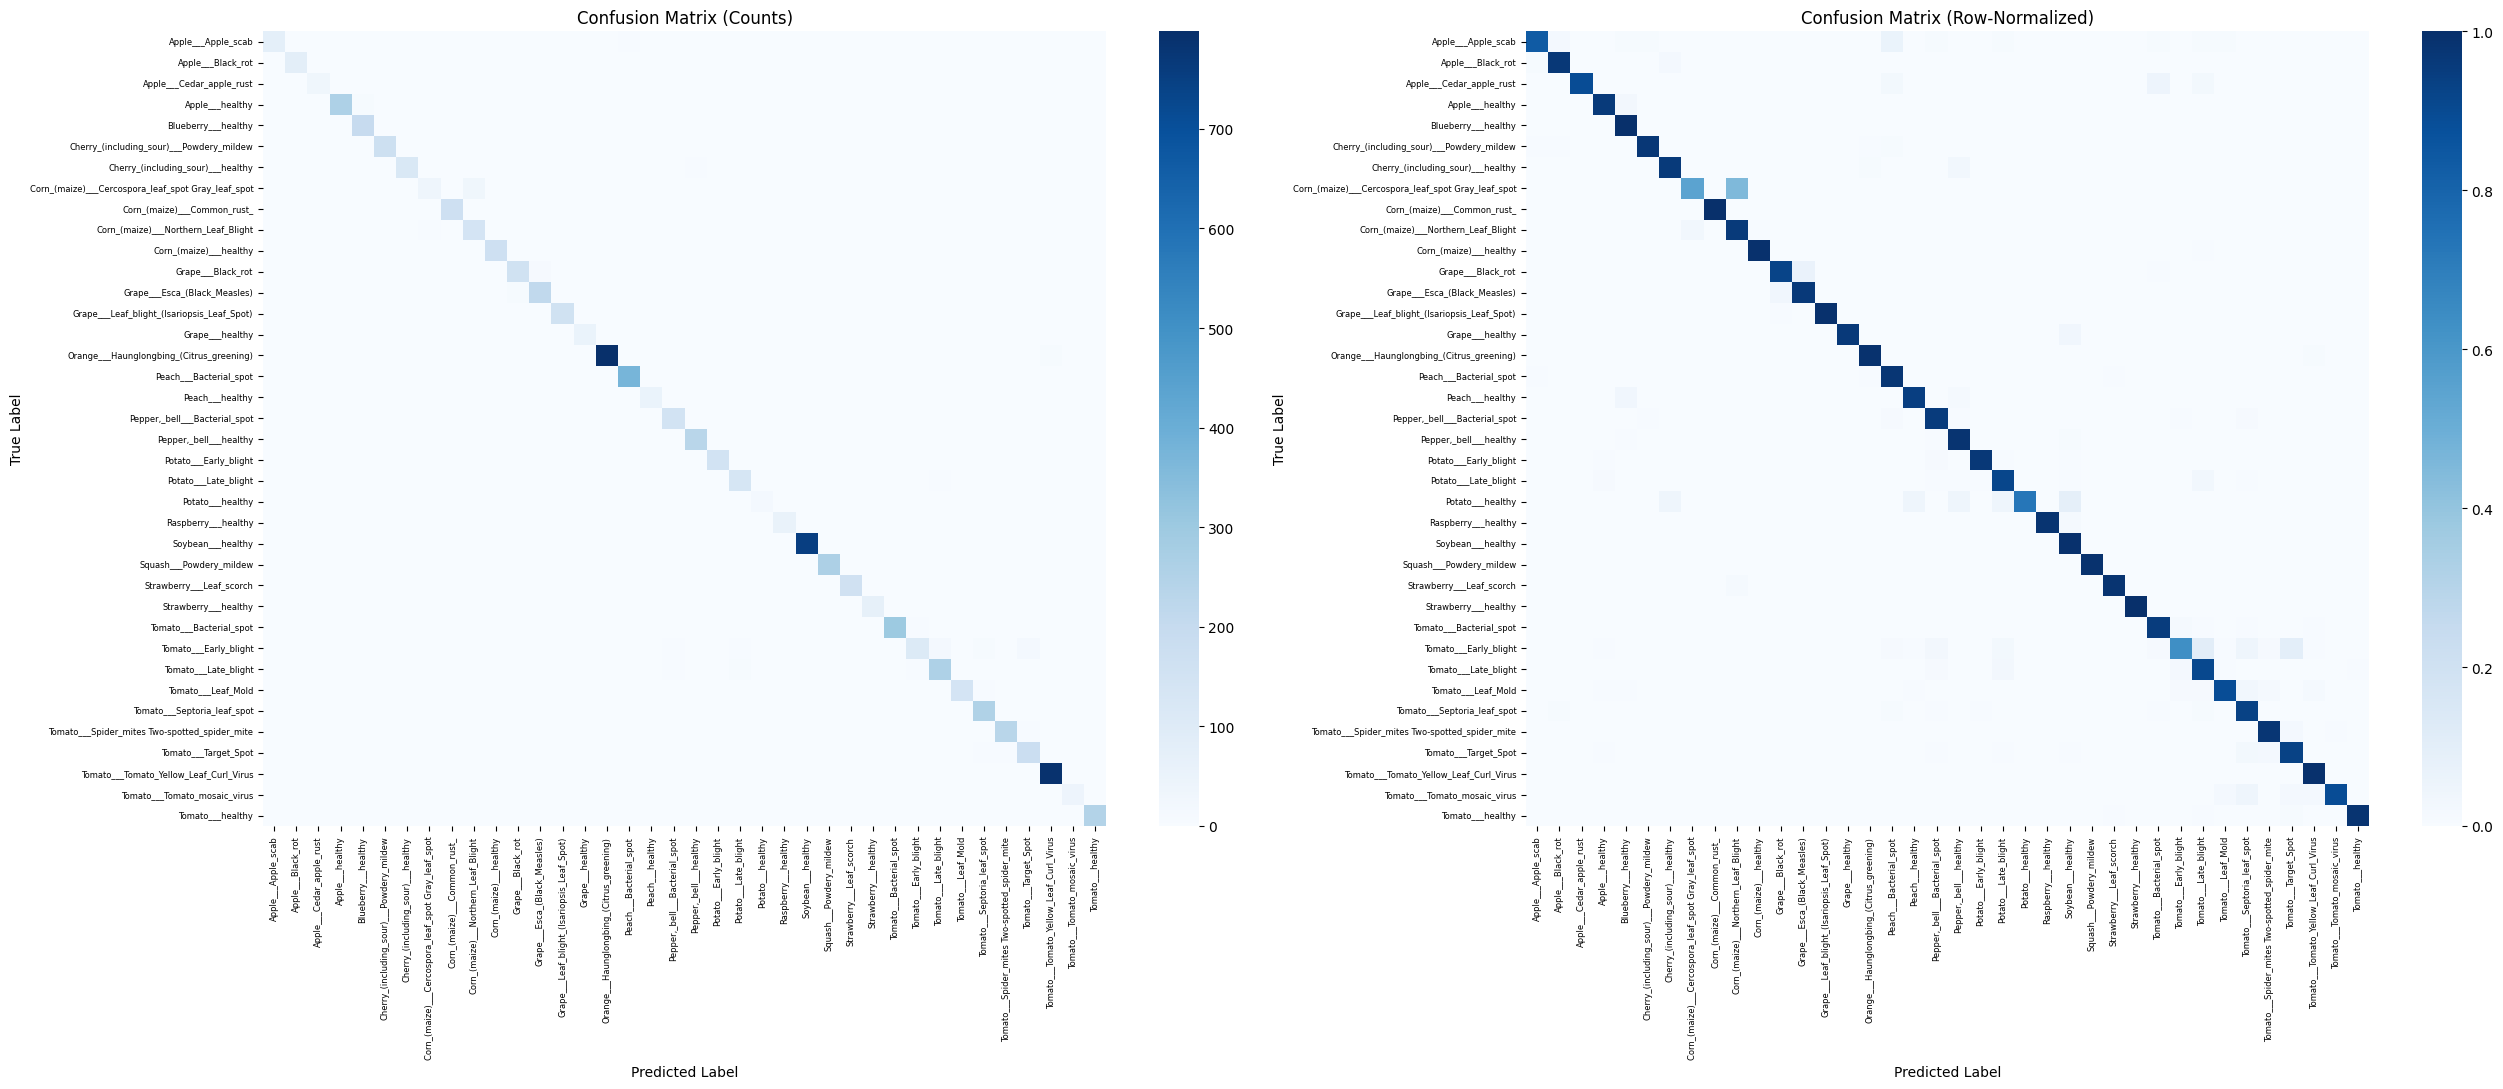

In [11]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(26, 11))

sns.heatmap(cm, annot=False, cmap='Blues', fmt='g', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=90, labelsize=6)
axes[0].tick_params(axis='y', rotation=0, labelsize=6)

sns.heatmap(cm_normalized, annot=False, cmap='Blues', vmin=0, vmax=1, ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Confusion Matrix (Row-Normalized)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=90, labelsize=6)
axes[1].tick_params(axis='y', rotation=0, labelsize=6)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Per-Class Precision, Recall & F1 (Diagram)

A class-by-class breakdown — useful for identifying which specific plant
diseases the model struggles with most, which is good discussion material for
the thesis.

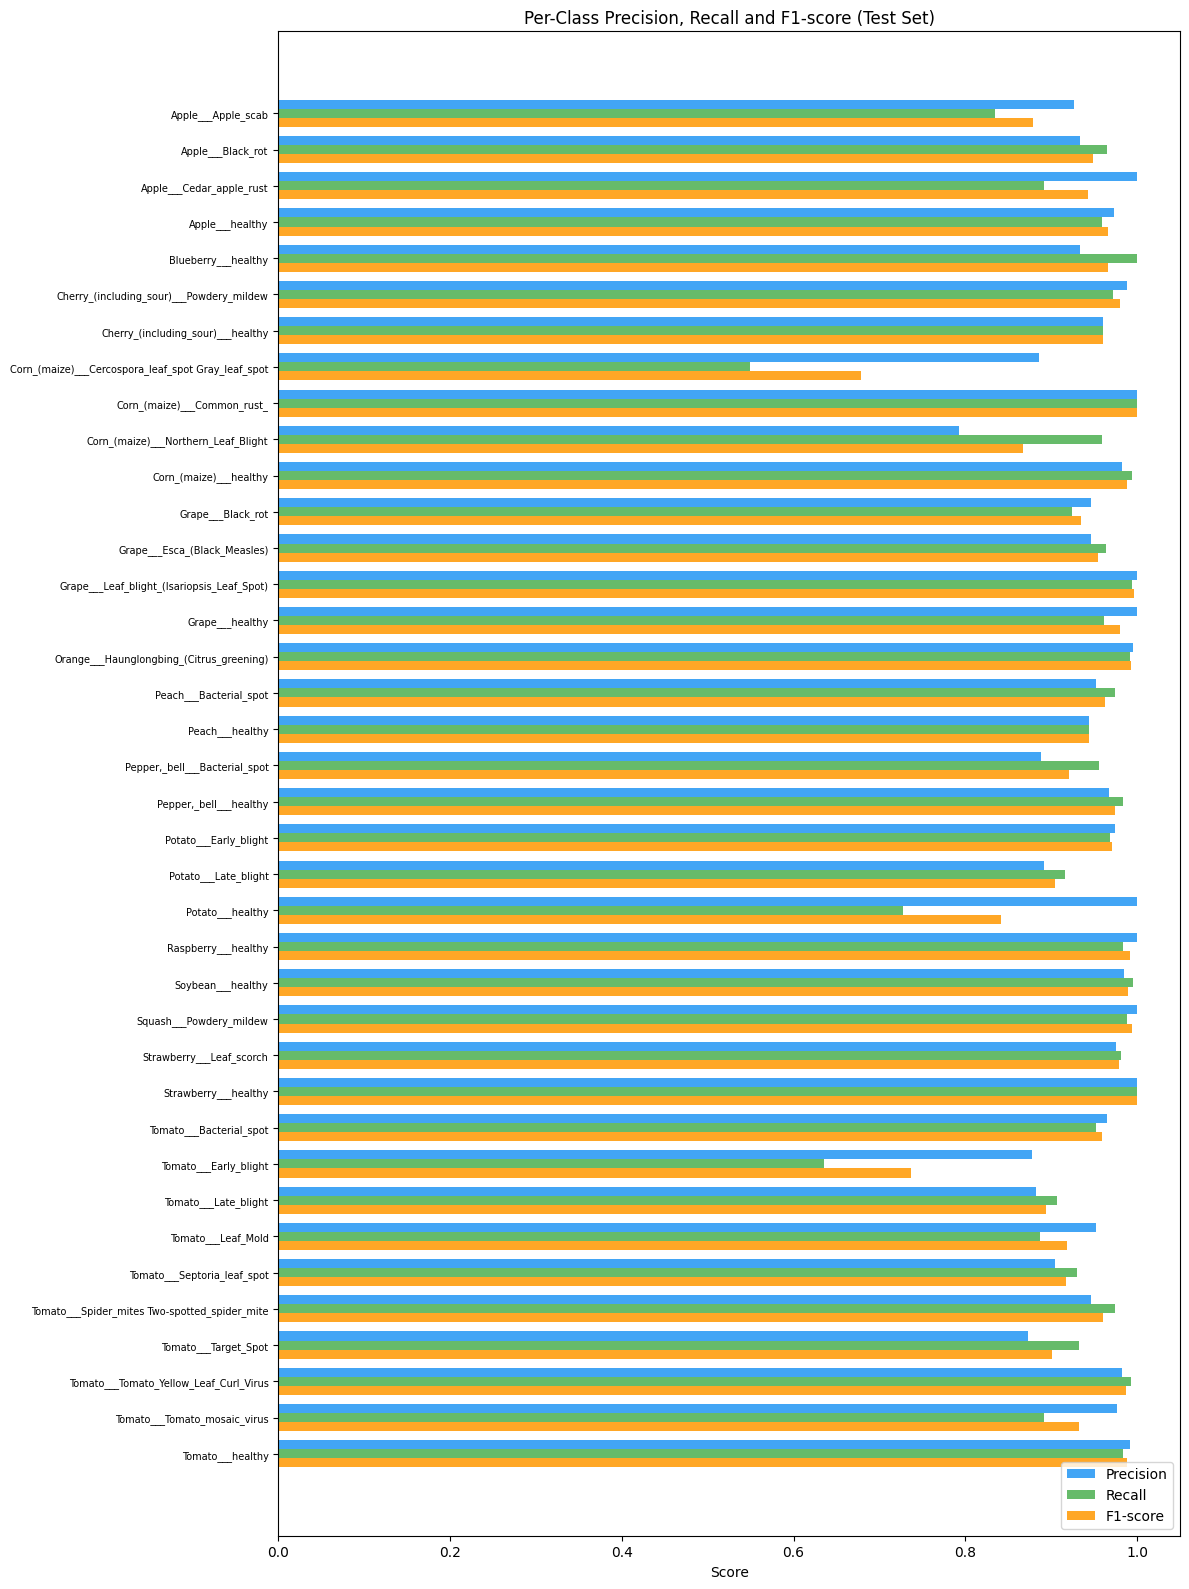

In [12]:
precision_per_class = precision_score(all_labels, all_preds, average=None, zero_division=0)
recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
f1_per_class = f1_score(all_labels, all_preds, average=None, zero_division=0)

x = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(12, 16))
bar_h = 0.25

ax.barh(x - bar_h, precision_per_class, height=bar_h, label='Precision', color='#42A5F5')
ax.barh(x, recall_per_class, height=bar_h, label='Recall', color='#66BB6A')
ax.barh(x + bar_h, f1_per_class, height=bar_h, label='F1-score', color='#FFA726')

ax.set_yticks(x)
ax.set_yticklabels(class_names, fontsize=7)
ax.set_xlabel('Score')
ax.set_title('Per-Class Precision, Recall and F1-score (Test Set)')
ax.set_xlim(0, 1.05)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: ROC Curves (Multi-Class, One-vs-Rest)

Micro- and macro-averaged ROC curves summarize discrimination ability across all
38 classes in a single plot (per-class ROC curves for 38 classes would be too
cluttered to be useful in a report).

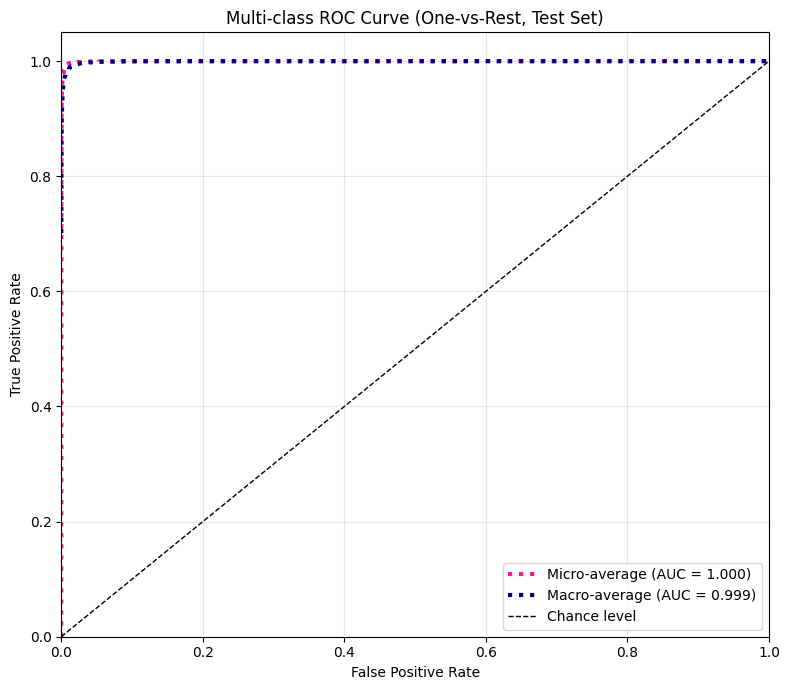

Mean per-class AUC: 0.9992


In [13]:
y_test_bin = label_binarize(all_labels, classes=list(range(num_classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average (aggregate all classes' TP/FP counts)
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average (unweighted mean of per-class curves)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 7))
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})',
         color='deeppink', linestyle=':', linewidth=3)
plt.plot(fpr["macro"], tpr["macro"], label=f'Macro-average (AUC = {roc_auc["macro"]:.3f})',
         color='navy', linestyle=':', linewidth=3)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance level')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (One-vs-Rest, Test Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

mean_per_class_auc = np.mean([roc_auc[i] for i in range(num_classes)])
print(f"Mean per-class AUC: {mean_per_class_auc:.4f}")

## Step 13: Metrics Summary Table

A compact table — paste this directly into the results chapter.

In [14]:
summary_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1-score (Macro)',
               'Precision (Weighted)', 'Recall (Weighted)', 'F1-score (Weighted)',
               'Mean ROC-AUC (Macro)', 'Best Epoch', 'Total Epochs Run'],
    'Value': [f"{test_accuracy*100:.2f}%", f"{precision_macro:.4f}", f"{recall_macro:.4f}",
              f"{f1_macro:.4f}", f"{precision_weighted:.4f}", f"{recall_weighted:.4f}",
              f"{f1_weighted:.4f}", f"{roc_auc['macro']:.4f}", early_stopper.best_epoch,
              len(history['train_loss'])]
})
summary_df

,Metric,Value
0,Test Accuracy,95.75%
1,Precision (Macro),0.9524
2,Recall (Macro),0.9322
3,F1-score (Macro),0.9396
4,Precision (Weighted),0.9580
5,Recall (Weighted),0.9575
6,F1-score (Weighted),0.9566
7,Mean ROC-AUC (Macro),0.9993
8,Best Epoch,24
9,Total Epochs Run,25


## Step 14: Evaluate a Single Image (with Confidence Chart)

Tests the model on one image and shows the top-5 predicted classes with their
confidence scores — useful for qualitative examples in the report.

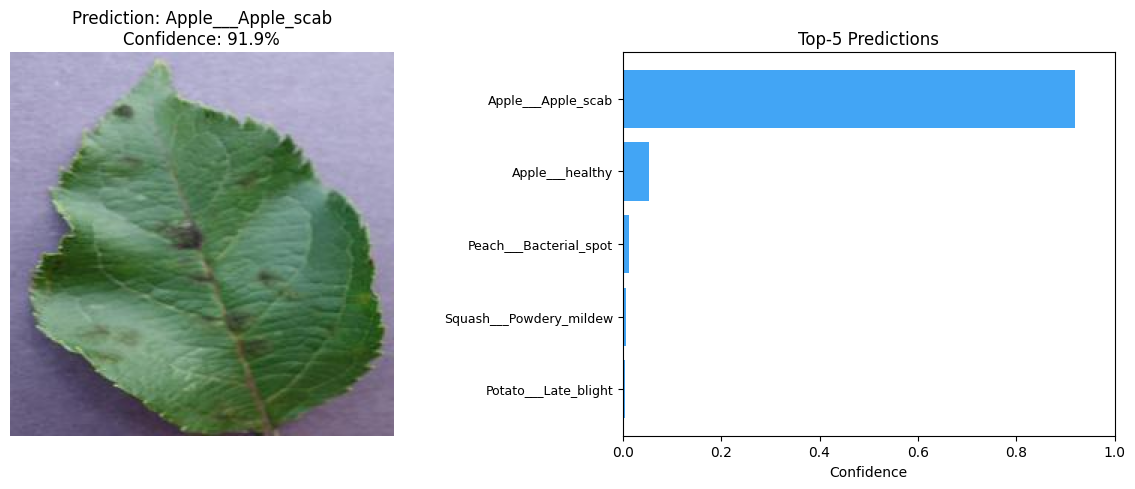

('Apple___Apple_scab', np.float32(0.91852385))

In [18]:
def predict_single_image(image_path, model, transform, class_names, top_k=5):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1).squeeze(0).cpu().numpy()

    top_idx = probs.argsort()[::-1][:top_k]
    top_labels = [class_names[i] for i in top_idx]
    top_scores = probs[top_idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(image)
    axes[0].set_title(f"Prediction: {top_labels[0]}\nConfidence: {top_scores[0]*100:.1f}%")
    axes[0].axis('off')

    axes[1].barh(range(top_k), top_scores[::-1], color='#42A5F5')
    axes[1].set_yticks(range(top_k))
    axes[1].set_yticklabels(top_labels[::-1], fontsize=9)
    axes[1].set_xlabel('Confidence')
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f'Top-{top_k} Predictions')

    plt.tight_layout()
    plt.show()

    return top_labels[0], top_scores[0]

# Example usage (replace with a valid path from your test set):
test_image_path = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG"
predict_single_image(test_image_path, model, eval_transform, class_names)

## Step 15: Save the Final Model

In [19]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes,
    'best_epoch': early_stopper.best_epoch,
    'test_accuracy': test_accuracy,
}, 'plantvillage_cnn_final.pt')

print("Model saved to plantvillage_cnn_final.pt")

Model saved to plantvillage_cnn_final.pt


## Notes for the Thesis Report

**Figures to include in the results chapter** (all saved as PNG files in this
notebook's working directory):
- `architecture_diagram.png` — Methodology / Model Design section
- `training_curves.png` — Training behaviour / convergence discussion
- `confusion_matrix.png` — Error analysis
- `per_class_metrics.png` — Per-class performance discussion
- `roc_curve.png` — Discrimination ability (AUC)

**On "efficient epochs":** rather than reporting a single fixed epoch count, the
thesis can state that training used early stopping (patience = 5, monitored on
validation loss) with a maximum budget of 25 epochs, and report the *actual*
epoch at which the best validation loss occurred (`early_stopper.best_epoch`,
also shown in the summary table). This is a stronger methodological statement
than a fixed epoch count, since it shows the epoch budget was chosen empirically
rather than guessed.

**On evaluation metrics:** report the test-set accuracy, macro/weighted
precision, recall and F1 from Step 9, alongside the confusion matrix and
per-class chart for qualitative discussion of which diseases are most often
confused.